# Chapter 5: Getting Started with pandas

## 5.2 Essential Functionality

### Arithmetic and Data Alignment
- When you are adding together objects, if any index pairs are not the same, the respective index in the result will be **the union of the index pairs**. For users with database experience, this is similar to an automatic outer join on the index labels.

In [8]:
df1 = pd.DataFrame(np.arange(9.).reshape((3,3)),
                  columns=list('bcd'), index=['Ohio', 'Texas','Colorado'])
df2 = pd.DataFrame(np.arange(12.).reshape((4,3)), columns=list('bde'),
                  index=['Utah', 'Ohio', 'Texas', 'Oregon'])
print(df1)
print(df2)

            b    c    d
Ohio      0.0  1.0  2.0
Texas     3.0  4.0  5.0
Colorado  6.0  7.0  8.0
          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0


In [9]:
df1 + df2

,b,c,d,e
Colorado,NaN,NaN,NaN,NaN
Ohio,3.0,NaN,6.0,NaN
Oregon,NaN,NaN,NaN,NaN
Texas,9.0,NaN,12.0,NaN
Utah,NaN,NaN,NaN,NaN


- Since the 'c' and 'e' columns are not found in both DataFrame objects, they appear as all missing in the result. The same holds for the rows whose labels are not common to both objects.

#### Arithmetic methods with fill values
- Using the add method on df1, and an argument to ***fill_value***:
- List of Series and DataFrame methods for arithmetic
    - add(+), sub(-), div(/)
    - floordiv(//), mul(\*), pow(\**)
    - Each of them has a counterpart, starting with the letter r, that has arguments flipped. ex) radd, rdiv, rpow

In [11]:
df1.add(df2, fill_value=0)

,b,c,d,e
Colorado,6.0,7.0,8.0,NaN
Ohio,3.0,1.0,6.0,5.0
Oregon,9.0,NaN,10.0,11.0
Texas,9.0,4.0,12.0,8.0
Utah,0.0,NaN,1.0,2.0


#### Operations between DataFrame and Series
- Operations between a DataFrame and a Series are similar to NumPy arrays: (***Broadcasting***)

In [2]:
frame =  pd.DataFrame(np.arange(12.).reshape((4,3)),
                     columns=list('bde'),
                     index=['Utah','Ohio','Texas','Oregon'])
series = frame.iloc[0]
print(frame)
print(series)

          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0
b    0.0
d    1.0
e    2.0
Name: Utah, dtype: float64


- By default, arithmetic between DataFrame and Series **matches the index of the Series on the DataFrame’s columns**, broadcasting down the rows

In [3]:
frame - series

,b,d,e
Utah,0.0,0.0,0.0
Ohio,3.0,3.0,3.0
Texas,6.0,6.0,6.0
Oregon,9.0,9.0,9.0


- If an index value is not found in either the DataFrame's columns or the Series's index, the objects will be reindexed to form the union:

In [4]:
series2 = pd.Series(range(3), index=['b', 'e', 'f'])
frame + series2

,b,d,e,f
Utah,0.0,NaN,3.0,NaN
Ohio,3.0,NaN,6.0,NaN
Texas,6.0,NaN,9.0,NaN
Oregon,9.0,NaN,12.0,NaN


- **If you want to instead broadcast over the columns, matching on the rows, you have to use one of the arithmetic method**:

In [5]:
series3 = frame['d']

In [6]:
frame.sub(series3, axis='index')

,b,d,e
Utah,-1.0,0.0,1.0
Ohio,-1.0,0.0,1.0
Texas,-1.0,0.0,1.0
Oregon,-1.0,0.0,1.0


### Function Application and Mapping
- NumPy ufuncs(element-wise array method) also work with pandas objects:

In [8]:
frame = pd.DataFrame(np.random.randn(4,3), columns=list('bde'),
                    index=['Utah','Ohio','Texas','Oregon'])
frame

,b,d,e
Utah,0.427919,0.482504,1.186852
Ohio,-0.645449,0.463612,-0.558274
Texas,-0.064517,-1.320542,0.077825
Oregon,-0.329628,-1.399807,-0.282756


In [13]:
np.abs(frame) # 보여주기만 바뀜, 원본 변화 x

,b,d,e
Utah,0.427919,0.482504,1.186852
Ohio,0.645449,0.463612,0.558274
Texas,0.064517,1.320542,0.077825
Oregon,0.329628,1.399807,0.282756


- Another frequent operation is **applying a function on one-dimenstional arrays to each column or row** :

In [15]:
f = lambda x: x.max() - x.min()
frame.apply(f)

b    1.073369
d    1.882311
e    1.745126
dtype: float64

- applied once on **each column in *frame***. The result is a Series having **the columns of *frame* as its index**
- If you pass ***axis = 'columns'*** to apply, the function will be invoked ***once per row*** instead: 
- The function passed to *apply* need not return a scalar value; it can also return a Series with multiple values:

In [21]:
def f(x):
    return pd.Series([x.min(), x.max()], index=['min', 'max'])

In [22]:
frame.apply(f)

,b,d,e
min,-0.645449,-1.399807,-0.558274
max,0.427919,0.482504,1.186852


In [23]:
frame.apply(f, axis='columns')

,min,max
Utah,0.427919,1.186852
Ohio,-0.645449,0.463612
Texas,-1.320542,0.077825
Oregon,-1.399807,-0.282756


- for Series, ***map***
- for DataFrame, ***applymap***

In [25]:
format = lambda x: '%.2f' %x

In [26]:
# Series
frame['e'].map(format)

Utah       1.19
Ohio      -0.56
Texas      0.08
Oregon    -0.28
Name: e, dtype: object

In [27]:
# DataFrame
frame.applymap(format)

,b,d,e
Utah,0.43,0.48,1.19
Ohio,-0.65,0.46,-0.56
Texas,-0.06,-1.32,0.08
Oregon,-0.33,-1.40,-0.28


### Sorting and Ranking
- To sort lexicographically by row or column index, use the ***sort_index*** method, which returns a new, sorted object

In [5]:
frame = pd.DataFrame(np.arange(8).reshape((2,4)),
                    index=['three', 'one'],
                    columns=['d','a','b','c'])
frame2 = frame.sort_index()
frame2

,d,a,b,c
one,4,5,6,7
three,0,1,2,3


In [6]:
frame2.sort_index(axis=1, ascending=False)

,d,c,b,a
one,4,7,6,5
three,0,3,2,1


- To sort **a Series** by its values, use its ***sort_values*** method
- Any missing valuse are sorted to the end of the Series by default

In [7]:
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])
obj.sort_values()

4   -3.0
5    2.0
0    4.0
2    7.0
1    NaN
3    NaN
dtype: float64

- When sorting a DataFrame, you can use the data in **one or more columns as the sort keys**. To do so, pass one or more column names to the **by option of *sort_values***:

In [15]:
frame = pd.DataFrame({'b':[4,7,-3,2], 'a':[0,1,0,1]})
frame.sort_values(by='b')

,b,a
2,-3,0
3,2,1
0,4,0
1,7,1


In [12]:
frame.sort_values(by=['a','b'])

,b,a
2,-3,0
0,4,0
3,2,1
1,7,1


- Ranking assigns ranks from one through the number of valid data points in an array.  The rank methods for Series and DataFrame are the place to look; **by default rank breaks ties by assigning each group the mean rank**:

>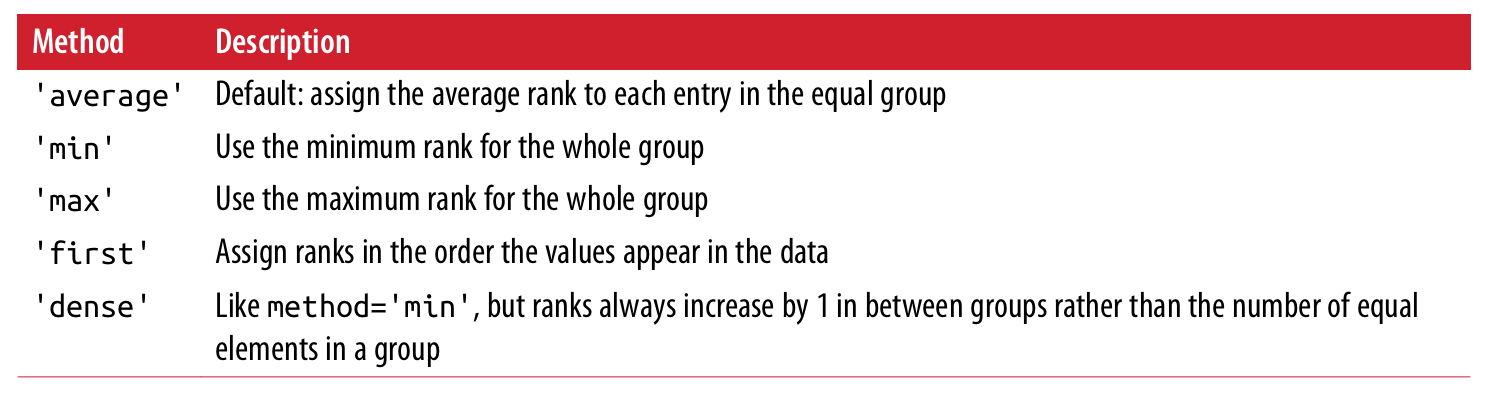

In [2]:
obj = pd.Series([7,-5,7,4,2,0,4])
obj.rank() # method='first' or 'max' or 'min'...

0    6.5
1    1.0
2    6.5
3    4.5
4    3.0
5    2.0
6    4.5
dtype: float64

In [18]:
frame = pd.DataFrame({'a':[0,1,0,1], 'b':[4.3,7,-3,2], 'c':[-2,5,8,-2.5]})
frame

,a,b,c
0,0,4.3,-2.0
1,1,7.0,5.0
2,0,-3.0,8.0
3,1,2.0,-2.5


In [17]:
frame.rank(axis='columns')

,a,b,c
0,2.0,3.0,1.0
1,1.0,3.0,2.0
2,2.0,1.0,3.0
3,2.0,3.0,1.0


### Axis Indexes with Duplicate Labels
- The index’s ***is_unique*** property can tell you whether its labels are unique or not:

In [4]:
obj = pd.Series(range(5), index=['a','a','b','b','c'])
df = pd.DataFrame(np.random.randn(4,3), index=['a','a','b','b'])

In [3]:
obj['a'] # 중복: series -> series

a    0
a    1
dtype: int64

In [4]:
obj['c'] # 단독: series -> scalar

4

In [5]:
df.loc['a'] # 중복: df -> df

,0,1,2
a,1.260188,-0.565595,-0.152344
a,-0.052065,-0.481060,-0.415224
